# Precipitator Unit Model Tutorial

In this tutorial, we demonstrate how to build, simulate, and optimize a precipitation
unit model using the PrOMMiS and IDAES modeling framework.

In this tutorial we will learn how to:

1. Build a flowsheet and a precipitation unit model
2. Initialize and solve the process model
3. Perform sensitivity analysis on acid dosage
4. Visualize the results
5. Formulate and solve an optimization problem to determine optimal condition

![unit.png](./unit.png)

The flowsheet consists of a feed stream entering a precipitation unit where
oxalic acid is added to induce precipitation of target metal species.
The model predicts the conversion (precipitation fraction) of the dissolved
species as a function of acid dosage.

# Step 1. Setting Up the Flowsheet and Unit Model

In this section, we set up the process model for the precipitator unit model.

The workflow includes:

1. Import required Python libraries
2. Create a flowsheet and add the precipitation unit model
3. Specify operating condition
5. Initialize and solve the model

Once the flowsheet is created, the model variables and constraints
can be used for simulation, sensitivity analysis, and optimization in the later sections.

## 1.1 Importing Necessary Libraries

This section imports the Python packages required to construct and solve
the precipitation unit model. 

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from pyomo.environ import (
    Objective,
    ConcreteModel,
    Constraint,
    units,
    value,
)


from idaes.core import FlowsheetBlock
from idaes.core.solvers import get_solver

import idaes.logger as idaeslog

from prommis.properties.mixed_acid_properties import (
    MixedAcidParameterBlock,
)
from prommis.precipitate.precipitate_solids_properties_isotherm import (
    PrecipitateParameters,
)
from prommis.precipitate.precipitate_reactions import OxalatePrecipitationReactions
from prommis.precipitate.precipitator_isotherm import (
    OxalatePrecipitatorScaler,
    OxalatePrecipitator,
    OxalatePrecipitatorInitializer,
)

# Import Pyomo's math and parameter estimation libraries
import pyomo.environ as pyo
from pyomo.environ import exp, log
import pyomo.contrib.parmest.parmest as parmest
from pyomo.contrib.parmest.experiment import Experiment

# Import degrees of freedom function from IDAES for sanity check
from idaes.core.util.model_statistics import degrees_of_freedom

# Import data frame, math and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1.2 Create the Flowsheet and Add the Precipitator Unit Model

In this section, we construct the process flowsheet and add the precipitation
unit model.

The flowsheet serves as the top-level container that organizes all unit
models and streams within the process.

The precipitation unit model represents a reactor in which dissolved
species react with oxalic acid to form solid precipitates. The model
tracks the conversion of each species as a function of acid dosage.

Once the flowsheet structure is created, the process variables can be
specified and solved.

In [25]:
_log = idaeslog.getLogger(__name__)

# Create m (model)
m = ConcreteModel()

# Add flowsheet
m.fs = FlowsheetBlock(dynamic=False)

# Call solid and liquid properties
m.fs.properties_aq = MixedAcidParameterBlock(include_oxalates=True)
m.fs.properties_solid = PrecipitateParameters()

# Call reactions
m.fs.prec_rxns = OxalatePrecipitationReactions()


<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
Let's create a precipitator unit model with:
    
Number of tanks = 1
    
Liquid phase: 
"property_package": m.fs.properties_aq,
"has_energy_balance": False,
"has_pressure_balance": False
    
and,
    
Solid phase: 
"property_package": m.fs.properties_solid,
"has_energy_balance": False,
"has_pressure_balance": False  
    
</div>

In [26]:
# TODO: Add unit model to flowsheet


In [27]:
# TODO: Add unit model to flowsheet
m.fs.precipitator = OxalatePrecipitator(
    number_of_tanks=1,
    liquid_phase={
        "property_package": m.fs.properties_aq,
        "has_energy_balance": False,
        "has_pressure_balance": False,
    },
    solid_phase={
        "property_package": m.fs.properties_solid,
        "has_energy_balance": False,
        "has_pressure_balance": False,
    },
    reaction_package=m.fs.prec_rxns,
)

## 1.3 Add Operating Conditions

In this section, we specify the operating conditions required to fully
define the process model.

Typical operating conditions include:

- Feed flow rate
- Feed composition
- Oxalic acid dosage
- Temperature and pressure

These variables represent process inputs that determine how the system
operates and returns.

Many of these variables are fixed so that the model becomes deterministic. 
Later in the tutorial some of these variables will be
unfixed and treated as decision variables for optimization.


In [28]:
Temp_room = 303 * units.K
P_atm = 101235 * units.Pa
eps=1e-8

# Assuming pH is 1.16 -> 8000 mgH2C2O4/L
m.fs.precipitator.mscontactor.liquid_inlet.flow_vol.fix(50)
m.fs.precipitator.mscontactor.liquid_inlet.pressure.fix(P_atm)
m.fs.precipitator.mscontactor.liquid_inlet.temperature.fix(Temp_room)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2O"].fix(1000000)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H_+"].fix(eps)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "HC2O4_-"].fix(eps)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "C2O4_2-"].fix(eps)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"].fix(8000)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Cl_-"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Al_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Ca_2+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Fe_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Sc_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Y_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "La_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Ce_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Pr_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Nd_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Sm_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Gd_3+"].fix(100)
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "Dy_3+"].fix(100)

m.fs.precipitator.precipitate_outlet.temperature.fix(Temp_room)
m.fs.precipitator.hydraulic_retention_time[0].fix(2)

<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
Let's fix the temperature to Temp_room and the hydraulic retention time to 2 hours. 
</div>

In [29]:
# TODO: Fix temperature of the precipitate_outlet to Temp_room


# TODO: Fix the hydraulic_retention_time[0] to 2 hours


In [30]:
# TODO: Fix temperature of the precipitate_outlet to Temp_room
m.fs.precipitator.precipitate_outlet.temperature.fix(Temp_room)

# TODO: Fix the hydraulic_retention_time[0] to 2 hours
m.fs.precipitator.hydraulic_retention_time[0].fix(2)

## 1.3 Select and Configure the Solver

Once the operating condition is defined, a numerical
solver is required to compute the solution.

In this tutorial we use **IPOPT**, a nonlinear optimization solver widely
used for solving large-scale nonlinear programming problems.

In [31]:
solver = get_solver("ipopt_v2")

### 1.4 Initialize the Unit Model

During initialization, the model variables are given reasonable starting
values so that the nonlinear solver can converge to a valid solution.

Without good initial guesses, nonlinear solvers may fail to converge or
may converge to nonphysical solutions.

IDAES provides initialization routines that sequentially solve simplified
versions of the model to generate good starting points for the model.

In [32]:
initializer_precip = OxalatePrecipitatorInitializer()

initializer_precip.initialize(m.fs.precipitator)

2026-09-15 12:41:27 [INFO] idaes.init.fs.precipitator.mscontactor: Stream Initialization Completed.
2026-09-15 12:41:27 [INFO] idaes.init.fs.precipitator.mscontactor: Initialization Completed, optimal - <undefined>
Ipopt 3.13.2: linear_solver="ma57"
max_iter=200
nlp_scaling_method="gradient-based"
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    

<InitializationStatus.Ok: 1>

## 1.5 Solve the Unit Model

After defining operating condition and initializing the model, we are now able to solve
the flowsheet.

Solving the model can determine the steady-state values of all variables.

The resulting solution represents the baseline process performance for
the specified operating condition.

<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
We have now initialized the flowsheet. Let us run the flowsheet in a simulation mode to look at the results. 
</div>

In [33]:
# TODO: Add results and run solver.solve(m, tee = True)

In [34]:
# TODO: Add results and run solver.solve(m, tee = True)
results = solver.solve(m, tee=True)

Ipopt 3.13.2: linear_solver="ma57"
max_iter=200
nlp_scaling_method="gradient-based"
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collect

In [35]:
m.fs.precipitator.display()

Block fs.precipitator

  Variables:
    hydraulic_retention_time : Hydraulic retention time
        Size=1, Index=fs._time, Units=h
        Key : Lower : Value : Upper : Fixed : Stale : Domain
        0.0 :     0 :     2 :  None :  True :  True : NonNegativeReals
    volume : Volume of precipitator
        Size=1, Index=fs._time, Units=l
        Key : Lower : Value : Upper : Fixed : Stale : Domain
        0.0 :     0 : 100.0 :  None : False : False : NonNegativeReals
    conversion : Conversion of each precipitation species
        Size=12, Index=fs.prec_rxns.reaction_idx, Units=dimensionless
        Key           : Lower : Value                 : Upper    : Fixed : Stale : Domain
        Al2(C2O4)3(s) : 1e-20 : 0.0054975221639376815 : 0.999999 : False : False :  Reals
          Ca(C2O4)(s) : 1e-20 :                 1e-06 : 0.999999 : False : False :  Reals
        Ce2(C2O4)3(s) : 1e-20 :    0.9946033546658058 : 0.999999 : False : False :  Reals
        Dy2(C2O4)3(s) : 1e-20 :    0.909

In [36]:
m.fs.precipitator.mscontactor.solid[0.0,1].display()

Block fs.precipitator.mscontactor.solid[0.0,1]

  Variables:
    temperature : Temperature
        Size=1, Index=None, Units=K
        Key  : Lower  : Value : Upper : Fixed : Stale : Domain
        None : 298.15 : 303.0 :  None :  True :  True :  Reals
    flow_mol_comp : Size=12, Index={Al2(C2O4)3(s), Ca(C2O4)(s), Fe2(C2O4)3(s), Sc2(C2O4)3(s), Y2(C2O4)3(s), La2(C2O4)3(s), Ce2(C2O4)3(s), Pr2(C2O4)3(s), Nd2(C2O4)3(s), Sm2(C2O4)3(s), Gd2(C2O4)3(s), Dy2(C2O4)3(s)}, Units=mol/h
        Key           : Lower : Value                 : Upper : Fixed : Stale : Domain
        Al2(C2O4)3(s) : 1e-25 : 0.0005093699096006301 :  None : False : False :  Reals
          Ca(C2O4)(s) : 1e-25 : 6.287836219372222e-08 :  None : False : False :  Reals
        Ce2(C2O4)3(s) : 1e-25 :    0.0177460708036378 :  None : False : False :  Reals
        Dy2(C2O4)3(s) : 1e-25 :  0.013994756475551047 :  None : False : False :  Reals
        Fe2(C2O4)3(s) : 1e-25 :  0.010788157305047978 :  None : False : False :  Reals

## Section 2. Parameter estimation

The model describes precipitation conversion as a function of oxalic
acid dosage using a nonlinear expression:

$Conversion = \exp\left(-\frac{\epsilon}{\text{Oxalic Acid Dosage}^{n_{DA}}}\right)$

In this sectionwe will perform a paramter estimation of the unknown parameters:

- $\epsilon$ (eps) — a model coefficient controlling precipitation intensity
- n_DA — an exponent describing the acid dosage sensitivity


## Step 2 Sensitivity Analysis Over Acid Dosage

In this section, a sensitivity analysis is conducted to investigate how
precipitation performance changes with oxalic acid dosage.

The procedure involves solving the model multiple times while varying
the oxalic acid dosage over a specified range.

In [37]:
for item in m.fs.properties_solid.component_list:
    metal = item[:1] if item.startswith("Y") else item[:2]
    
    # Creates global variables like Al_oxalate = []
    variable_name = f"{metal}_oxalate"
    variable_name_2 = f"{metal}_recovery"
    
    globals()[variable_name] = []
    
    globals()[variable_name_2] = []  
    
# Generate array for oxalic acid dosage
oxalic_acid = np.linspace(4000, 10000, 10)

for i in range(len(oxalic_acid)):

    m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"].fix(oxalic_acid[i])
 
    results = solver.solve(m, tee=False)
    
    for item in m.fs.properties_solid.component_list:
        metal = item[:1] if item.startswith("Y") else item[:2] 
        
        # Store metal oxalate outlet
        # Calculate and store recovery        
        if metal == "Ca":
            globals()[f"{metal}_oxalate"].append(value(
                m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, f"{metal}(C2O4)(s)"]))
            globals()[f"{metal}_recovery"].append(value(m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, "Ca(C2O4)(s)"]/
                             (m.fs.precipitator.mscontactor.liquid_inlet_state[0.0].flow_mol_comp["Ca_2+"])))
        else: 
            globals()[f"{metal}_oxalate"].append(value(
                m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, f"{metal}2(C2O4)3(s)"]))
            globals()[f"{metal}_recovery"].append(value(
                m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, f"{metal}2(C2O4)3(s)"]*2/
                             (m.fs.precipitator.mscontactor.liquid_inlet_state[0.0].flow_mol_comp[f"{metal}_3+"])))



## Step 3 Results Visualization

After performing the sensitivity analysis, the results are visualized
using plots.

The plots illustrate how the different oxalic acid dosage affects the
fraction of species that precipitate.

The first figure shows the mole fraction of each metal oxalate in the outlet stream as a function of oxalic acid dosage.

The second figure shows the extent of each metal being recovered after the precipitator as a function of oxalic acid dosage.

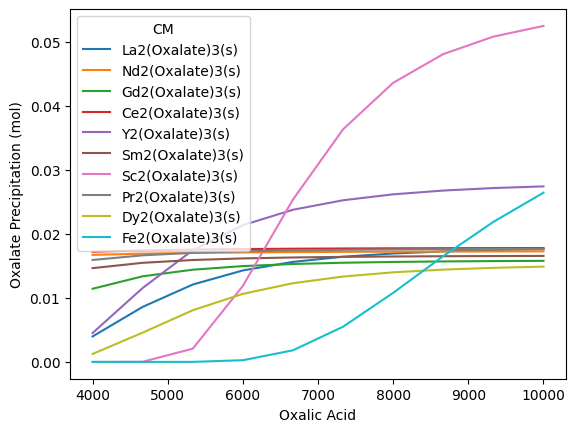

In [38]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

metals_to_plot = ["La", "Nd", "Gd", "Ce", "Y", "Sm", "Sc", "Pr", "Dy", "Fe"]

for metal in metals_to_plot:
    
    # 1. Extract the data array
    raw_data = globals()[f"{metal}_oxalate"]

    # 2. Extract the actual data elements from the wrapper
    if len(raw_data) == 1 and hasattr(raw_data[0], '__len__'):
        y_data = raw_data[0] # Strips the outer bracket layer
    else:
        y_data = raw_data

    label_name = f"{metal}2(Oxalate)3(s)" if metal != "Ca" else "Ca(Oxalate)(s)"

    # This will now match dimensions perfectly
    ax.plot(oxalic_acid, y_data, label=label_name)

# Format the plot
ax.legend(title='CM')
ax.set_xlabel("Oxalic Acid")
ax.set_ylabel("Oxalate Precipitation (mol)")
plt.show()

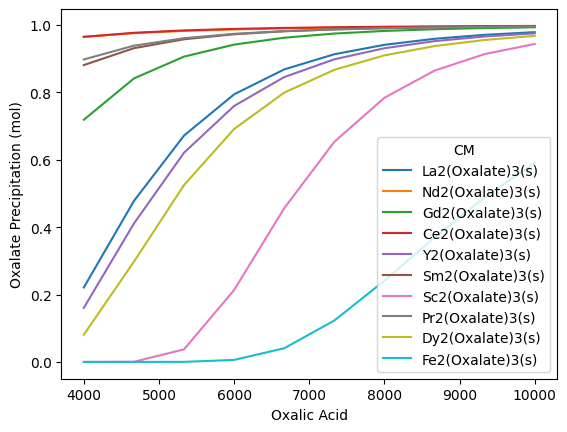

In [39]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

metals_to_plot = ["La", "Nd", "Gd", "Ce", "Y", "Sm", "Sc", "Pr", "Dy", "Fe"]

for metal in metals_to_plot:
    
    # 1. Extract the data array
    raw_data = globals()[f"{metal}_recovery"]

    # 2. Extract the actual data elements from the wrapper
    if len(raw_data) == 1 and hasattr(raw_data[0], '__len__'):
        y_data = raw_data[0] # Strips the outer bracket layer
    else:
        y_data = raw_data

    label_name = f"{metal}2(Oxalate)3(s)" if metal != "Ca" else "Ca(Oxalate)(s)"

    # This will now match dimensions perfectly
    ax.plot(oxalic_acid, y_data, label=label_name)

# Format the plot
ax.legend(title='CM')
ax.set_xlabel("Oxalic Acid")
ax.set_ylabel("Oxalate Precipitation (mol)")
plt.show()

# Step 4. Process Optimization

In this section, we solve the optimization problem to
determine the optimal operating conditions for the precipitation unit model.

Optimization allows us to determine the best operating strategy based
on a specified objective, such as:

- Maximizing precipitation conversion
- Minimizing oxalic acid consumption

The optimization problem is constructed by defining:

1. Decision variables
2. An objective function
3. Process constraints

The solver then determines the operating conditions that achieve the
best performance according to the defined objective.

## 4.1 Unfix Variables

Before performing optimization, certain variables must be unfixed so
that the solver can adjust them.

In this tutorial, the oxalic acid dosage is treated as a decision
variable.

By unfixing this variable, the solver is allowed to search for the
dosage that produces the best process performance according to the
objective function.

<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
Let's reinitialize and unfix the conc_mass_comp of $H_2C_2O_4$. 
</div>

In [40]:
# TODO: Fix to initialize m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"] to 8000


# TODO: Unfix the initialized variable


In [41]:
# TODO: Fix to initialize m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"] to 8000
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"].fix(8000)

# TODO: Unfix the initialized variable
m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"].unfix()

## 4.2 Add Objective Function and Constraints

In this section, we define the optimization problem, which consists of objective function and constraints.

Together, the objective function and constraints define the feasible
region and the optimization goal.

<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
Let's add the objective of minimizing the conc_mass_comp of $H_2C_2O_4$. 
</div>

In [42]:
# TODO: Create an objective minimizing the liquid inlet conc_mass_comp variable for "H2C2O4"

m.fs.dy_conversion = Constraint(expr=m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, "Dy2(C2O4)3(s)"]*2/
                             (m.fs.precipitator.mscontactor.liquid_inlet_state[0.0].flow_mol_comp["Dy_3+"]) >= 0.90)

# TODO: Create a constraint to limit the amount of Fe2(C2O4)3(S) to 0.01 in the precipitate_outlet


In [43]:
# TODO: Create an objective minimizing the liquid inlet conc_mass_comp variable for "H2C2O4"
m.fs.objective = Objective(expr = m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"])

m.fs.dy_conversion = Constraint(expr=m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, "Dy2(C2O4)3(s)"]*2/
                             (m.fs.precipitator.mscontactor.liquid_inlet_state[0.0].flow_mol_comp["Dy_3+"]) >= 0.90)

# TODO: Create a constraint to limit the amount of Fe2(C2O4)3(S) to 0.01 in the precipitate_outlet
m.fs.product_purity = Constraint(expr=m.fs.precipitator.precipitate_outlet.flow_mol_comp[0, "Fe2(C2O4)3(s)"] <= 0.01)

(type=<class 'pyomo.core.base.constraint.ScalarConstraint'>) on block fs with
a new Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().


## 4.3 Solve the Optimization Problem

After defining the decision variables, objective function, and
constraints, the optimization problem can be solved using the nonlinear
solver.

<div class="alert alert-block alert-info">
<b>Inline Exercise:</b>
Solve the optimization function. 
</div>

In [44]:
 # TODO: Run the solver


In [45]:
 # TODO: Run the solver
solver_options = {"tol": 1e-8, "max_iter": 1000}
results = solver.solve(m, solver_options=solver_options, tee=True)

Ipopt 3.13.2: linear_solver="ma57"
max_iter=1000
nlp_scaling_method="gradient-based"
tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collec

## 4.4 Print Optimization Result

In the final step, we display the optimization results with the optimal oxalic acid dosage.

This result can be used to help guide process design and operating decisions in
real precipitation systems for recovering critical minerals.

In [46]:
print("Oxalic acid dosage = ", value(m.fs.precipitator.mscontactor.liquid_inlet.conc_mass_comp[0, "H2C2O4"]), "mol/L")

Oxalic acid dosage =  7821.380753572215 mol/L
